In [18]:
import rasterio as rio
from rasterio.windows import Window
from rasterio.features import shapes
import geopandas as gpd
from glob import glob
from joblib import Parallel, delayed
import numpy as np
from tqdm.notebook import tqdm
from shapely.geometry import shape, Point, MultiPolygon
from shapely import STRtree
import os
import matplotlib.pyplot as plt
import pcxarray as pcx
from joblib import Parallel, delayed
import re
import math
from rtree import index
import rioxarray as rxr
from concurrent.futures import ThreadPoolExecutor, as_completed

tile_size = 256
target_resolution = 2.5  # meters per pixel

In [ ]:
os.makedirs('raster_temp', exist_ok=True)

# VRT files for CBLC 2024 edition can be downloaded from https://www.sciencebase.gov/catalog/item/66d099c9d34e98e8a924e574
for vrt_path in glob('./*.vrt'):
    
    tiff_path = os.path.join('raster_temp', os.path.basename(vrt_path).replace('.vrt', '.tif'))
    if not os.path.exists(tiff_path):
        with rio.open(vrt_path) as src:
            profile = src.profile
            profile.update(
                driver='GTiff',
                compress='lzw',
                tiled=True,
                blockxsize=512,
                blockysize=512,
                bigtiff='YES',
            )
            with rio.open(tiff_path, 'w', **profile) as dst:
                
                block_size = src.block_shapes[0][0]
                total_blocks = (src.width // block_size + 1) * (src.height // block_size + 1)
                for ji, window in tqdm(src.block_windows(1), desc=f'Writing {tiff_path}', total=total_blocks):
                    dst.write(src.read(window=window), window=window)

# merge rasters into one file
merged_tiff_path = 'chesapeake_bay_2022_2024edition.tif'
if not os.path.exists(merged_tiff_path):
    rio.merge.merge(
        glob('./raster_temp/*.tif'),
        dst_path=merged_tiff_path,
        method='max',
        use_highest_res =True,
        mem_limit=256,
        dst_kwds={
            'compress':'lzw',
            'bigtiff':'YES',
            'blockxsize':512,
            'blockysize':512,
            'tiled':True,
            'num_threads':'ALL_CPUS',
        }
    )

In [ ]:
def extract_footprint(raster_path: str, window_size: int=16384, n_jobs: int=16):
    
    with rio.open(raster_path) as src:
        raster_width = src.width
        raster_height = src.height
        
    windows = [
        Window(col_off, row_off, window_size, window_size)
        for col_off in range(0, raster_width, window_size)
        for row_off in range(0, raster_height, window_size)
    ]
    
    geoms = Parallel(n_jobs=n_jobs)(
        delayed(process_window)(raster_path, window)
        for window in tqdm(windows, desc=f'Processing {raster_path}')
    )
    
    geoms = [geom for sublist in geoms for geom in sublist]
    return raster_path, geoms

def process_window(raster_path: str, window: Window):
    with rio.open(raster_path) as src:
        transform = src.window_transform(window)
        mask = src.read(1, window=window) != src.nodata

    geoms = []
    for geom, value in shapes(mask.astype(np.uint8), mask=mask, transform=transform):
        if value: # Only keep geometries where mask is True
            geoms.append(shape(geom))
    
    return geoms


if os.path.exists('footprint.gpkg'):
    footprint_gdf = gpd.read_file('footprint.gpkg')
else:
    geom_lists = []
    for raster_path in glob('./raster_temp/*_lulc_*_2024-Edition.tif'):
        rp, geoms = extract_footprint(raster_path, window_size=4096, n_jobs=8)
        geom_lists.append((rp, geoms))
    
    geom_list_2 = [(rp, MultiPolygon(geoms)) for rp, geoms in geom_lists]
    footprint_gdf = gpd.GeoDataFrame(
        geom_list_2,
        columns=['raster_path', 'geometry'],
        crs=rio.open(glob('./raster_temp/*_lulc_*_2024-Edition.tif')[0]).crs
    )

    footprint_gdf = footprint_gdf.dissolve(by='raster_path').reset_index()
    footprint_gdf['year'] = footprint_gdf['raster_path'].apply(lambda x: int(re.search(r'lulc_(\d{4})_2024-Edition', x).group(1)))
    footprint_gdf['state'] = footprint_gdf['raster_path'].apply(lambda x: re.search(r'raster_temp/([A-Z]{2})_', x).group(1))
    footprint_gdf.to_file('footprint.gpkg', driver='GPKG')

In [ ]:
# footprint_gdf = gpd.GeoDataFrame(
#     geom_list_2,
#     columns=['raster_path', 'geometry'],
#     crs=rio.open(glob('./raster_temp/*_lulc_*_2024-Edition.tif')[0]).crs
# )

# footprint_gdf = footprint_gdf.dissolve(by='raster_path').reset_index()
footprint_gdf['year'] = footprint_gdf['raster_path'].apply(lambda x: int(re.search(r'lulc_(\d{4})_2024-Edition', x).group(1)))
footprint_gdf['state'] = footprint_gdf['raster_path'].apply(lambda x: re.search(r'raster_temp\\([A-Z]{2})_', x).group(1))
footprint_gdf.to_file('footprint.gpkg', driver='GPKG')

In [ ]:
s2_tiles_gdf = gpd.read_file(r"Z:\dbcenter\dbgis\sat_tiles\sentinel2msi\tiles\tiles.shp")
selected_s2_tiles_gdf = s2_tiles_gdf.loc[s2_tiles_gdf.intersects(footprint_gdf.simplify(10).buffer(100).to_crs(s2_tiles_gdf.crs).iloc[0])]
with open('s2_tiles_list.txt', 'w') as f:
    for tile_id in selected_s2_tiles_gdf['Name'].tolist():
        f.write(f"{tile_id}\n")

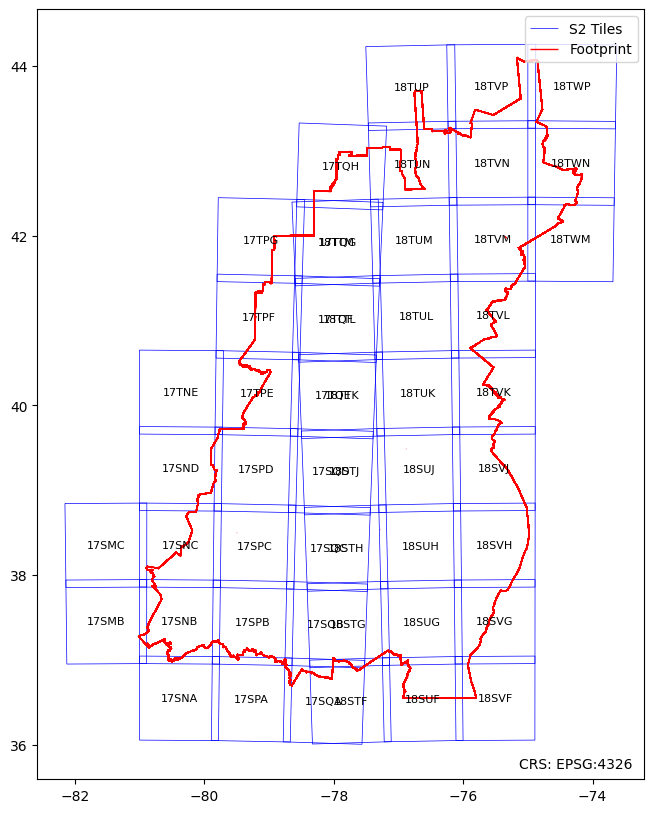

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
selected_s2_tiles_gdf.boundary.plot(ax=ax, color='blue', linewidth=0.5, label='S2 Tiles')
footprint_gdf.to_crs(s2_tiles_gdf.crs).boundary.plot(ax=ax, color='red', linewidth=1, label='Footprint')
# add projection info
ax.text(0.98, 0.02, f'CRS: {s2_tiles_gdf.crs.to_string()}', horizontalalignment='right', verticalalignment='center', transform=ax.transAxes)

# add tile labels
for idx, row in selected_s2_tiles_gdf.iterrows():
    centroid = row['geometry'].centroid
    ax.text(centroid.x, centroid.y, row['Name'], fontsize=8, ha='center', va='center')
plt.legend()

In [ ]:
naip_acqs = pcx.pc_query(
    collections=['naip'],
    geometry=footprint_gdf.simplify(100).buffer(100).to_crs(4326).geometry.iloc[0],
    crs=4326,
    datetime='2021/2022',
)

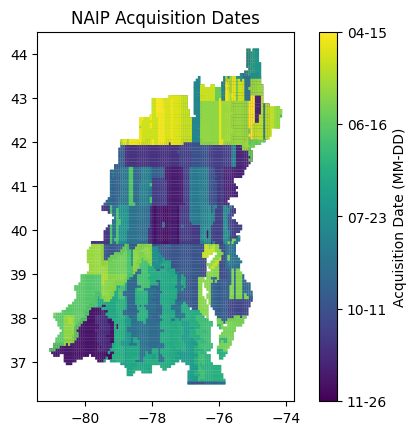

In [ ]:
naip_acqs['month_day'] = naip_acqs['properties.datetime'].dt.strftime('%m-%d')
# show continuous color map of acquisition dates
naip_acqs.plot(column='month_day', cmap='viridis', legend=False)
# show color bar with month-day labels
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=plt.gca(), orientation='vertical')
cbar.set_label('Acquisition Date (MM-DD)')

# show ticks for 5 total unique month-day values
cbar.set_ticks(np.linspace(0, 1, num=5))
unique_dates = naip_acqs['month_day'].unique()
unique_dates.sort()
unique_dates = unique_dates[::-1]
cbar.set_ticklabels(unique_dates[np.linspace(0, len(unique_dates)-1, num=5).astype(int)])


plt.title('NAIP Acquisition Dates')
plt.show()

In [ ]:
# download into one large raster file

os.makedirs('raster_temp', exist_ok=True)

for vrt_path in glob('./*.vrt'):
    
    tiff_path = os.path.join('raster_temp', os.path.basename(vrt_path).replace('.vrt', '.tif'))
    if not os.path.exists(tiff_path):
        with rio.open(vrt_path) as src:
            profile = src.profile
            profile.update(
                driver='GTiff',
                compress='lzw',
                tiled=True,
                blockxsize=512,
                blockysize=512,
                bigtiff='YES',
            )
            with rio.open(tiff_path, 'w', **profile) as dst:
                
                block_size = src.block_shapes[0][0]
                total_blocks = (src.width // block_size + 1) * (src.height // block_size + 1)
                for ji, window in tqdm(src.block_windows(1), desc=f'Writing {tiff_path}', total=total_blocks):
                    dst.write(src.read(window=window), window=window)



Writing raster_temp\DC_lulc_2021_2024-Edition.tif: 100%|██████████| 25696/25696 [00:16<00:00, 1586.19it/s]
Writing raster_temp\DE_lulc_2021_2024-Edition.tif: 100%|██████████| 920295/920295 [04:26<00:00, 3448.61it/s] 
Writing raster_temp\MD_lulc_2021_2024-Edition.tif: 100%|██████████| 5187855/5187855 [30:39<00:00, 2820.09it/s]  
Writing raster_temp\NY_lulc_2022_2024-Edition.tif: 100%|██████████| 5681124/5681124 [33:04<00:00, 2863.34it/s]  
Writing raster_temp\PA_lulc_2022_2024-Edition.tif: 100%|██████████| 6725300/6725300 [1:04:31<00:00, 1737.18it/s] 
Writing raster_temp\VA_lulc_2021_2024-Edition.tif: 100%|██████████| 9197379/9197379 [1:11:40<00:00, 2138.61it/s] 
Writing raster_temp\WV_lulc_2022_2024-Edition.tif: 100%|██████████| 4417905/4417905 [13:03<00:00, 5638.99it/s] 


In [ ]:
# merge rasters into one file
merged_tiff_path = 'chesapeake_bay_2022_2024edition.tif'
if not os.path.exists(merged_tiff_path):
    rio.merge.merge(
        glob('./raster_temp/*.tif'),
        dst_path=merged_tiff_path,
        method='max',
        use_highest_res =True,
        mem_limit=256,
        dst_kwds={
            'compress':'lzw',
            'bigtiff':'YES',
            'blockxsize':512,
            'blockysize':512,
            'tiled':True,
            'num_threads':'ALL_CPUS',
        }
    )

In [ ]:
# resample to 2.5 m
output_res = 2.5

with rio.open(merged_tiff_path) as src:
    src_res = src.res[0]  # assuming square pixels
    scale_factor = src_res / output_res
    
    data = src.read(
        out_shape=(
            src.count,
            int(src.height * scale_factor),
            int(src.width * scale_factor)
        ),
        resampling=rio.enums.Resampling.mode
    )
    transform = src.transform * src.transform.scale(
        (src.width / data.shape[-1]),
        (src.height / data.shape[-2])
    )
    
    profile = src.profile
    profile.update(
        height=data.shape[1],
        width=data.shape[2],
        transform=transform,
        compress='lzw',
        tiled=True,
        blockxsize=512,
        blockysize=512,
        bigtiff='YES',
    )
    
    with rio.open('chesapeake_bay_2022_2024edition_2.5m.tif', 'w', **profile) as dst:
        dst.write(data)
    

In [ ]:
cpb_reclassification_dict = {
    # --- 1. OPEN WATER ---
    10: 1,  # Tidal Waters [cite: 626]
    11: 1,  # Lakes and Reservoirs [cite: 646]
    12: 1,  # Riverine Ponds [cite: 655]
    13: 1,  # Terrene Ponds [cite: 670]
    14: 1,  # Streams and Rivers [cite: 678]

    # --- 2. HERBACEOUS / LOW VEGETATION ---
    27: 2,  # Turf Grass [cite: 773]
    34: 2,  # Solar Field Herbaceous [cite: 834]
    37: 2,  # Suspended Succession Herbaceous [cite: 865]
    43: 2,  # Natural Succession Herbaceous [cite: 927]
    46: 2,  # Harvested Forest Herbaceous [cite: 960]
    51: 2,  # Riverine Wetlands Non-forested Herbaceous [cite: 987]
    55: 2,  # Riverine Wetlands Harvested Forest (New in 2024) [cite: 1060]
    61: 2,  # Terrene Wetlands Non-forested Herbaceous [cite: 1100]
    65: 2,  # Terrene Wetlands Harvested Forest (New in 2024) [cite: 1180]
    71: 2,  # Tidal Wetlands Non-forested Herbaceous [cite: 1218]
    75: 2,  # Tidal Wetlands Harvested Forest (New in 2024) [cite: 1284]
    81: 2,  # Cropland Herbaceous [cite: 1313]
    83: 2,  # Orchards and Vineyards Herbaceous [cite: 1334]
    86: 2,  # Pasture and Hay Herbaceous [cite: 1368]

    # --- 3. WOODY VEGETATION / TREE CANOPY ---
    # Note: Includes Shrubland classes as they are biologically woody.
    23: 3,  # Tree Canopy over Roads [cite: 734]
    24: 3,  # Tree Canopy over Structures [cite: 741]
    25: 3,  # Tree Canopy over Impervious [cite: 755]
    26: 3,  # Tree Canopy over Turf Grass [cite: 761]
    35: 3,  # Solar Field Shrubland [cite: 840]
    38: 3,  # Suspended Succession Shrubland [cite: 884]
    40: 3,  # Forest [cite: 894]
    41: 3,  # Forested Other [cite: 907]
    44: 3,  # Natural Succession Shrubland [cite: 937]
    52: 3,  # Riverine Wetlands Non-forested Shrubland [cite: 1007]
    53: 3,  # Riverine Wetlands Forested Other [cite: 1018]
    54: 3,  # Riverine Wetlands Forest [cite: 1037]
    62: 3,  # Terrene Wetlands Non-forested Shrubland [cite: 1120]
    63: 3,  # Terrene Wetlands Forested Other [cite: 1132]
    64: 3,  # Terrene Wetlands Forest [cite: 1155]
    72: 3,  # Tidal Wetlands Non-forested Shrubland [cite: 1239]
    73: 3,  # Tidal Wetlands Forested Other [cite: 1252]
    74: 3,  # Tidal Wetlands Forest [cite: 1272]
    84: 3,  # Orchards and Vineyards Shrubland [cite: 1349]

    # --- 4. IMPERVIOUS ---
    20: 4,  # Roads [cite: 699]
    21: 4,  # Structures [cite: 713]
    22: 4,  # Other Impervious [cite: 719]
    31: 4,  # Extractive Impervious [cite: 803]
    32: 4,  # Solar Field Panel Arrays [cite: 817]

    # --- 5. BARREN ---
    15: 5,  # Bare Shore [cite: 695]
    28: 5,  # Bare Developed [cite: 781]
    30: 5,  # Extractive Barren [cite: 798]
    33: 5,  # Solar Field Barren [cite: 822]
    36: 5,  # Suspended Succession Barren [cite: 855]
    42: 5,  # Natural Succession Barren [cite: 913]
    45: 5,  # Harvested Forest Barren [cite: 954]
    50: 5,  # Riverine Wetlands Non-forested Barren [cite: 976]
    60: 5,  # Terrene Wetlands Non-forested Barren [cite: 1089]
    70: 5,  # Tidal Wetlands Non-forested Barren [cite: 1207]
    80: 5,  # Cropland Barren [cite: 1306]
    82: 5,  # Orchards and Vineyards Barren [cite: 1328]
    85: 5,  # Pasture and Hay Barren [cite: 1354]
}


cpb_colormap_consistent = {
    0: (0, 0, 0, 0),          # Nodata: Transparent (overrides #ffffff for GIS best practices)
    1: (81, 108, 151, 255),   # Open Water: #516c97
    2: (179, 253, 214, 255),  # Low Vegetation/Herbaceous: #b3fdd6
    3: (55, 120, 78, 255),    # Woody Vegetation/Tree Canopy: #37784e
    4: (152, 152, 153, 255),  # Impervious Surfaces/Structures: #989899
    5: (74, 37, 20, 255),     # Barren Land: #4a2514
}


with rio.open('chesapeake_bay_2022_2024edition_2.5m.tif') as src:
    profile = src.profile.copy()
    data = src.read(1)
    
# reclassify data in chunks to save memory
chunk_size = 1000
rows, cols = data.shape
for row_start in tqdm(list(range(0, rows, chunk_size))):
    row_end = min(row_start + chunk_size, rows)
    for col_start in range(0, cols, chunk_size):
        col_end = min(col_start + chunk_size, cols)
        chunk = data[row_start:row_end, col_start:col_end]
        reclassified_chunk = np.copy(chunk)
        for original_value, new_value in cpb_reclassification_dict.items():
            reclassified_chunk[chunk == original_value] = new_value
        data[row_start:row_end, col_start:col_end] = reclassified_chunk

with rio.open('chesapeake_bay_2022_2024edition_2.5m_reclassified.tif', 'w', **profile) as dst:
    dst.write(data, 1)
    dst.write_colormap(1, cpb_colormap_consistent)

100%|██████████| 349/349 [10:53<00:00,  1.87s/it]


In [ ]:
# add overviews
with rio.open('chesapeake_bay_2022_2024edition_2.5m_reclassified.tif', 'r+') as dst:
    factors = [2, 4, 8, 16, 32]
    dst.build_overviews(factors, rio.enums.Resampling.nearest)

In [ ]:
import pandas as pd

footprint_gdf = gpd.read_file('footprint.gpkg')
footprint_gdf_simplified = footprint_gdf.copy()
footprint_gdf_simplified['geometry'] = footprint_gdf.simplify(100).buffer(100).to_crs(4326)

footprint_gdf_simplified

naip_items = [
    pcx.pc_query(
        collections=['naip'],
        geometry=row['geometry'],
        crs=4326,
        datetime=str(row['year'])
    )
    for _, row in tqdm(footprint_gdf_simplified.iterrows(), total=len(footprint_gdf_simplified), desc='Querying NAIP acquisitions')
]

naip_items_gdf = gpd.GeoDataFrame(pd.concat(naip_items, ignore_index=True), crs=4326)

Querying NAIP acquisitions: 100%|██████████| 7/7 [00:00<00:00, 23.71it/s]


In [ ]:
from joblib import Parallel, delayed

def determine_locations(naip_item_row, date_offset: int=3):
    
    dt_start = naip_item_row['properties.datetime'] - np.timedelta64(date_offset, 'D')
    dt_end = naip_item_row['properties.datetime'] + np.timedelta64(date_offset, 'D')
    # print(f"NAIP date: {naip_item_row['properties.datetime'].date()}, searching for S2 from {dt_start.date()} to {dt_end.date()}")
    
    s2_items_gdf = pcx.pc_query(
        collections=['sentinel-2-l2a'],
        geometry=naip_item_row['geometry'],
        crs=4326,
        datetime=f'{dt_start.date()}/{dt_end.date()}',
    )
    
    geom = s2_items_gdf.geometry.union_all()
    return {
        'naip_datetime': naip_item_row['properties.datetime'],
        'geometry': naip_item_row.geometry.intersection(geom)
    }

candidate_regions = Parallel(n_jobs=16, backend='threading')(
    delayed(determine_locations)(row)
    for idx, row in tqdm(naip_items_gdf.iterrows(), total=len(naip_items_gdf), desc='Determining candidate regions')
)

Determining candidate regions:   2%|▏         | 192/8322 [00:09<07:38, 17.75it/s]d:\chesapeake_bay_2022_2024edition\.venv\lib\site-packages\pcxarray\query.py:157: UserWarning: No items found for the given query. Returning empty GeoDataFrame.
  warn("No items found for the given query. Returning empty GeoDataFrame.")
d:\chesapeake_bay_2022_2024edition\.venv\lib\site-packages\pcxarray\query.py:157: UserWarning: No items found for the given query. Returning empty GeoDataFrame.
  warn("No items found for the given query. Returning empty GeoDataFrame.")
d:\chesapeake_bay_2022_2024edition\.venv\lib\site-packages\pcxarray\query.py:157: UserWarning: No items found for the given query. Returning empty GeoDataFrame.
  warn("No items found for the given query. Returning empty GeoDataFrame.")
d:\chesapeake_bay_2022_2024edition\.venv\lib\site-packages\pcxarray\query.py:157: UserWarning: No items found for the given query. Returning empty GeoDataFrame.
  warn("No items found for the given query. Ret

330.0


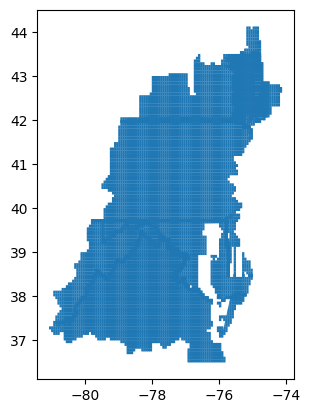

In [ ]:
tile_size = 256 # in pixels
target_resolution = 2.5 # in meters

buffer_size_m = (tile_size * target_resolution) / 2
buffer_size_m += 10 # add 10m extra buffer to be safe
print(buffer_size_m)

candidate_regions_gdf = candidate_regions_gdf = gpd.GeoDataFrame(candidate_regions, geometry='geometry', crs=naip_items_gdf.crs)
# candidate_regions_gdf = candidate_regions_gdf.dissolve()
# candidate_regions_gdf['geometry'] = candidate_regions_gdf.to_crs(footprint_gdf.crs).geometry.intersection(footprint_gdf.simplify(10).union_all().buffer(-buffer_size_m)) 
# candidate_regions_gdf = candidate_regions_gdf.explode()
candidate_regions_gdf.plot()
candidate_regions_gdf.to_file('candidate_regions.gpkg')

In [ ]:
max_num_samples = 70000
min_sample_dist = 1500 # minimum distance between samples
tile_size = 256 # in pixels
target_resolution = 2.5 # in meters

candidate_regions_gdf = gpd.read_file('candidate_regions.gpkg')
candidate_regions_projected_gdf = candidate_regions_gdf.to_crs(epsg=5070)

valid_regions_strtree = STRtree(candidate_regions_projected_gdf.geometry)
invalid_regions_rtree = index.Index() 
pixel_buffer = int(math.ceil((tile_size * target_resolution) / 2.0))

minx, miny, maxx, maxy = candidate_regions_projected_gdf.total_bounds

n_points = max_num_samples
sampled_points = []
np.random.seed(1701)

with tqdm(desc='Sampling points', total=n_points) as pbar:
    while len(sampled_points) < n_points:
        
        sample_x = np.random.uniform(minx, maxx)
        sample_y = np.random.uniform(miny, maxy)
        sample_point = Point(sample_x, sample_y)
        
        is_valid_region = False
        for potential_intersection in valid_regions_strtree.query(sample_point):
            if candidate_regions_projected_gdf.iloc[potential_intersection].geometry.contains(sample_point.buffer(pixel_buffer)):
                is_valid_region = True
                break
        
        if not is_valid_region:
            continue
        
        for potential_intersection in invalid_regions_rtree.intersection(sample_point.bounds):
            if sampled_points[potential_intersection].buffer(min_sample_dist).intersects(sample_point):
                is_valid_region = False
                break
            
        if not is_valid_region:
            continue
        
        invalid_regions_rtree.insert(len(sampled_points), sample_point.buffer(min_sample_dist).bounds)
        sampled_points.append(sample_point)
        pbar.update(1)

sampled_points_gdf = gpd.GeoDataFrame(geometry=sampled_points, crs=candidate_regions_projected_gdf.crs)
n_digits = len(str(len(sampled_points_gdf) - 1))
sampled_points_gdf['id'] = sampled_points_gdf.index.map(lambda x: str(x).zfill(n_digits))


Sampling points: 100%|██████████| 70000/70000 [06:53<00:00, 169.22it/s] 


<Axes: >

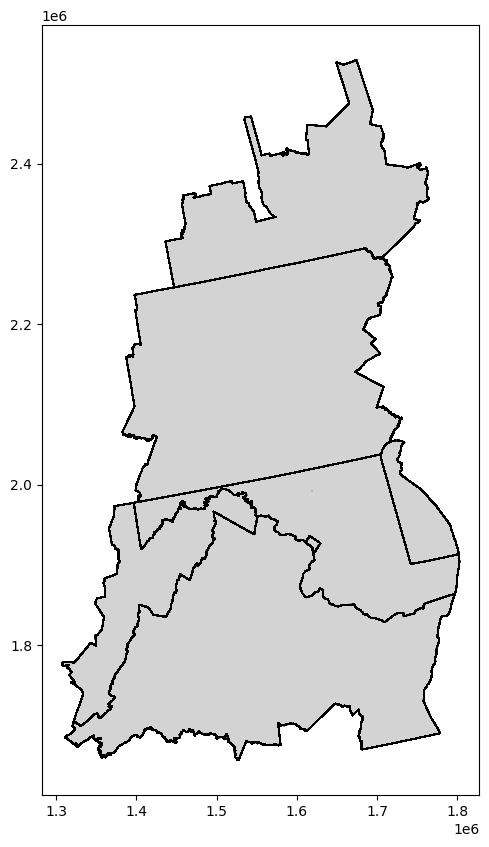

In [ ]:
footprint_gdf = gpd.read_file('footprint.gpkg')



In [38]:
sampled_points_joined_gdf = sampled_points_gdf.sjoin(
    footprint_gdf.to_crs(sampled_points_gdf.crs),
    how='inner',
    predicate='within'
)

In [44]:
sampled_points_joined_gdf['sample_geom'] = sampled_points_joined_gdf.geometry.buffer((tile_size * target_resolution) / 2.0).envelope
sampled_points_joined_gdf.to_parquet('sampled_points.par')  

<Axes: >

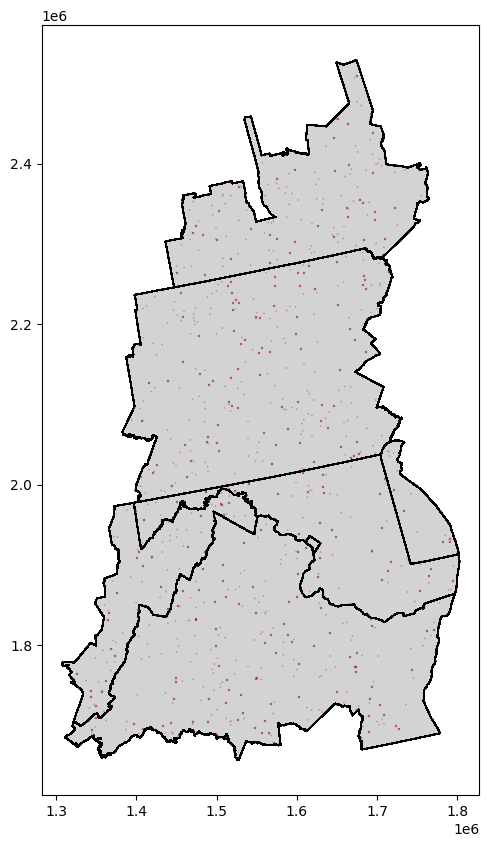

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
footprint_gdf.plot(ax=ax, color='lightgrey', edgecolor='black')

sampled_points_joined_gdf.sample(1000)['sample_geom'].plot(ax=ax, color='red', alpha=0.5, edgecolor='darkred')

In [6]:
from pathlib import Path
import os
import sys
from pathlib import Path
# Find the pyproj data directory
proj_data_dir = Path(sys.executable).parent.parent / 'Lib' / 'site-packages' / 'pyproj' / 'proj_dir' / 'share' / 'proj'
if proj_data_dir.exists():
    os.environ['PROJ_LIB'] = str(proj_data_dir)
else:
    # Fallback for conda environments
    proj_data_dir_conda = Path(sys.executable).parent.parent / 'Library' / 'share' / 'proj'
    if proj_data_dir_conda.exists():
        os.environ['PROJ_LIB'] = str(proj_data_dir_conda)
    else:
        pass
        # print("Warning: Could not automatically find PROJ data directory.")

import rasterio as rio
import rioxarray as rxr
import pandas as pd

from warnings import filterwarnings
filterwarnings('ignore')

sampled_points_joined_gdf = gpd.read_parquet('sampled_points.par')

valid_scl_values = [0, 4, 5, 6]

def download_tile(row, date_offset=3, resolution=2.5, tile_size=256, crs=5070):
    tile_id = row['id']
    # print(f"\n--- Processing tile: {tile_id} ---")
    try:
        # Create output directories if they don't exist
        naip_path = Path('samples') / 'naip' / f"{tile_id}.tif"
        s2_path = Path('samples') / 'sentinel2' / f"{tile_id}.tif"
        lc_path = Path('samples') / 'landcover' / f"{tile_id}.tif"
        naip_path.parent.mkdir(parents=True, exist_ok=True)
        s2_path.parent.mkdir(parents=True, exist_ok=True)
        lc_path.parent.mkdir(parents=True, exist_ok=True)

        if naip_path.exists() and s2_path.exists() and lc_path.exists():
            # print(f"[{tile_id}] All files already exist. Skipping.")
            return

        # 1. Check Land Cover data
        data_path = row['raster_path'].replace('raster_temp', 'raster_temp_processed')
        # print(f"[{tile_id}] Checking Land Cover data from: {data_path}")
        lc_data = rxr.open_rasterio(data_path).rio.clip_box(*row['sample_geom'].buffer(10).bounds)
        lc_data = lc_data.rio.clip([row['sample_geom']], all_touched=True)
        
        # Ensure correct shape (handle cases where clip is slightly off)
        if lc_data.shape[-2:] != (tile_size, tile_size):
            # print(f"[{tile_id}] LC data shape is {lc_data.shape[-2:]}, trimming to {(tile_size, tile_size)}.")
            lc_data = lc_data.isel(x=slice(0, tile_size), y=slice(0, tile_size))

        if 0 in lc_data.values: # 0 is implicit nodata
            # print(f"[{tile_id}] Found NoData (0) in Land Cover data. Skipping tile.")
            return
        # print(f"[{tile_id}] Land Cover data is valid.")

        # 2. Find NAIP data
        # print(f"[{tile_id}] Querying NAIP for year {row['year']}...")
        naip_items_gdf = pcx.pc_query(
            collections='naip',
            geometry=row['sample_geom'],
            datetime=str(row['year']),
            crs=crs,
        )
        if len(naip_items_gdf) == 0:
            # print(f"[{tile_id}] No NAIP items found for the given geometry and year. Skipping tile.")
            return
        # print(f"[{tile_id}] Found {len(naip_items_gdf)} NAIP items. Preparing data...")

        naip_xr = pcx.prepare_data(
            naip_items_gdf,
            geometry=row['sample_geom'].buffer(10),
            crs=crs,
            target_resolution=resolution,
            resampling_method='lanczos',
            all_touched=True,
        ).rio.clip([row['sample_geom']], all_touched=True)
        
        if naip_xr.shape[-2:] != (tile_size, tile_size):
            # print(f"[{tile_id}] NAIP data shape is {naip_xr.shape[-2:]}, trimming to {(tile_size, tile_size)}.")
            naip_xr = naip_xr.isel(x=slice(0, tile_size), y=slice(0, tile_size))

        if naip_xr.isnull().values.any():
            # print(f"[{tile_id}] Found null values in prepared NAIP data. Skipping tile.")
            return
        # print(f"[{tile_id}] NAIP data prepared successfully.")

        # 3. Find Sentinel-2 data
        naip_datetime = pd.to_datetime(naip_items_gdf['properties.datetime'].iloc[0])
        dt_start = naip_datetime - pd.Timedelta(days=date_offset)
        dt_end = naip_datetime + pd.Timedelta(days=date_offset)
        dt_range = f"{str(dt_start.date())}/{str(dt_end.date())}"
        geom = row['sample_geom'].buffer(10)
        
        # print(f"[{tile_id}] NAIP date is {naip_datetime.date()}. Querying Sentinel-2 from {dt_start.date()} to {dt_end.date()}.")
        s2_items_gdf = pcx.pc_query(
            collections='sentinel-2-l2a',
            geometry=geom,
            datetime=dt_range,
            crs=crs,
        )
        
        if s2_items_gdf.empty:
            # print(f"[{tile_id}] No Sentinel-2 items found in date range. Skipping tile.")
            return
        # print(f"[{tile_id}] Found {len(s2_items_gdf)} Sentinel-2 items. Searching for best cloud-free image...")

        s2_data = None
        dts = s2_items_gdf['properties.datetime'].unique()
        dts = sorted(dts, key=lambda x: abs((pd.to_datetime(x) - naip_datetime).days))
        
        for dt in dts:
            # print(f"[{tile_id}] -- Checking S2 image from {pd.to_datetime(dt).date()}...")
            s2_items_dt_gdf = s2_items_gdf.loc[s2_items_gdf['properties.datetime'] == dt]
            
            s2_scl = pcx.prepare_data(
                s2_items_dt_gdf, bands=['SCL'], geometry=geom, crs=crs, all_touched=True
            )
            s2_scl = s2_scl.rio.reproject_match(naip_xr, resampling=rio.enums.Resampling.nearest)
            s2_scl = s2_scl.where(s2_scl != 0)
            
            if not s2_scl.isin(valid_scl_values).all():
                # print(f"[{tile_id}] -- SCL check failed (contains clouds/shadows). Trying next image.")
                continue
            
            # print(f"[{tile_id}] -- SCL check passed. Preparing 4-band data...")
            s2_candidate = pcx.prepare_data(
                s2_items_dt_gdf,
                bands=['B04', 'B03', 'B02', 'B08'],
                geometry=geom, crs=crs, all_touched=True
            )
            s2_candidate = s2_candidate.rio.reproject_match(naip_xr, resampling=rio.enums.Resampling.lanczos)
            s2_candidate = s2_candidate.where(s2_candidate != 0)
            
            if s2_candidate.isnull().values.any():
                # print(f"[{tile_id}] -- Found null values in 4-band data. Trying next image.")
                continue
            
            # print(f"[{tile_id}] -- Valid Sentinel-2 image found for date {pd.to_datetime(dt).date()}!")
            s2_data = s2_candidate
            break # Exit loop once a valid image is found
        
        if s2_data is None:
            # print(f"[{tile_id}] No valid cloud-free Sentinel-2 images found in any of the {len(dts)} available dates. Skipping tile.")
            return
        
        # 4. Reproject, save, and finalize
        # print(f"[{tile_id}] Reprojecting S2 data to match NAIP...")
        s2_data = s2_data.rio.reproject_match(naip_xr, resampling=rio.enums.Resampling.lanczos)
        s2_data = s2_data.fillna(0).astype(np.uint16).rio.write_nodata(0)
        
        if s2_data.shape[-2:] != (tile_size, tile_size):
            # print(f"[{tile_id}] S2 data shape is {s2_data.shape[-2:]}, trimming to {(tile_size, tile_size)}.")
            s2_data = s2_data.isel(x=slice(0, tile_size), y=slice(0, tile_size))
        
        # print(f"[{tile_id}] Saving files to disk...")
        s2_data.rio.to_raster(s2_path, compress='LZW', tiled=True)
        naip_xr.rio.to_raster(naip_path, compress='LZW', tiled=True)
        
        # *** CRITICAL FIX: Use lc_data, not data ***
        lc_data.rio.to_raster(lc_path, compress='LZW', tiled=True)
        
        with rio.open(lc_path, 'r+') as dst:
            dst.write_colormap(1, cpb_colormap_consistent)
        
        # print(f"[{tile_id}] SUCCESS: All files downloaded and saved.")
        return s2_data, naip_xr, lc_data

    except Exception as e:
        print(f"!!!!!! ERROR processing tile {tile_id}: {e} !!!!!!")
        # raise e # Uncomment this if you want the loop to stop on an error
        return


# for _, row in tqdm(sampled_points_joined_gdf.iterrows(), total=len(sampled_points_joined_gdf), desc='Downloading tiles'):


# for _, row in tqdm(sampled_points_joined_gdf.iterrows(), total=len(sampled_points_joined_gdf), desc='Downloading tiles'):
    # data_tuple = download_tile(row)
    # if data_tuple is not None:
    #     break

# s2_data, naip_data, lc_data = data_tuple


# with ThreadPoolExecutor(max_workers=24) as executor:
#     futures = [executor.submit(download_tile, row) for _, row in tqdm(sampled_points_joined_gdf.iterrows(), total=len(sampled_points_joined_gdf), desc='Submitting download tasks')]
#     for future in tqdm(as_completed(futures), total=len(futures), desc='Processing downloads'):
#         try:
#             future.result()
#         except Exception as e:
#             raise e


In [22]:
# sample assessment points: 1,0000 per class:

lc_paths = glob('./samples/landcover/*.tif')
naip_paths = glob('./samples/naip/*.tif')
s2_paths = glob('./samples/sentinel2/*.tif')

lc_ids = [os.path.basename(p).replace('.tif', '') for p in lc_paths]
naip_ids = [os.path.basename(p).replace('.tif', '') for p in naip_paths]
s2_ids = [os.path.basename(p).replace('.tif', '') for p in s2_paths]

valid_ids = set(lc_ids).intersection(set(naip_ids)).intersection(set(s2_ids))
valid_ids = sorted(list(valid_ids))


samples_gdf = sampled_points_joined_gdf[sampled_points_joined_gdf['id'].isin(valid_ids)].copy().drop(columns=['index_right', 'sample_geom', 'raster_path'])
samples_gdf['naip_path'] = samples_gdf['id'].map(lambda x: f"./samples/naip/{x}.tif")
samples_gdf['s2_path'] = samples_gdf['id'].map(lambda x: f"./samples/sentinel2/{x}.tif")
samples_gdf['lc_path'] = samples_gdf['id'].map(lambda x: f"./samples/landcover/{x}.tif")

samples_gdf['split'] = ['train' if i % 5 != 0 else 'test' for i in range(len(samples_gdf))]

# on training samples ONLY, set a fold column for 5-fold cross validation. if split is test, fold is -1
np.random.seed(1701)
def assign_fold(row):
    if row['split'] == 'test':
        return -1
    else:
        return np.random.randint(0, 5)

samples_gdf['fold'] = samples_gdf.apply(assign_fold, axis=1)

samples_gdf.to_parquet('samples.par')
samples_gdf.to_file('train_samples_shapefile/train_samples.shp')

In [ ]:
# now do assessment points
from tqdm.notebook import tqdm

# define exclusion zone as being within 1000m of any training sample
buffer = 1000  # in meters
exclusion_zones_gdf = sampled_points_joined_gdf[sampled_points_joined_gdf['id'].isin(samples_gdf[samples_gdf['split'] == 'train']['id'])].copy()[['sample_geom']]
pixel_buffer = int(math.ceil((256 * 2.5) / 2.0)) # make sure assessment points are fully inside valid regions


exclusion_zones_gdf['geometry'] = exclusion_zones_gdf['sample_geom'].buffer(buffer)
exclusion_zones_gdf = exclusion_zones_gdf.drop(columns=['sample_geom'])
exclusion_zones_gdf = exclusion_zones_gdf.set_geometry('geometry')
exclusion_zones_gdf = exclusion_zones_gdf.set_crs(sampled_points_joined_gdf.crs)

# create spatial index for exclusion zones
exclusion_strtree = STRtree(exclusion_zones_gdf.geometry)
valid_regions_strtree = STRtree(footprint_gdf.to_crs(5070).geometry) # valid regions
invalid_regions_rtree = index.Index() # already sampled assessment points

sampled_assessment_points = []
assessment_points = {
    1: [],
    2: [],
    3: [],
    4: [],
    5: [],
    6: [],
    7: [],
}

assessment_classes = list(assessment_points.keys())
pbars = {
    k: tqdm(total=max_assessment_points_per_class, desc=f'Class {k}', position=i)
    for i, k in enumerate(assessment_classes)
}

max_assessment_points_per_class = 1000

minx, miny, maxx, maxy = footprint_gdf.total_bounds
np.random.seed(1701)

with tqdm(desc='Sampling assessment points', total=max_assessment_points_per_class * len(assessment_points)) as pbar:
    while any(len(v) < max_assessment_points_per_class for v in assessment_points.values()):
        sample_x = np.random.uniform(minx, maxx)
        sample_y = np.random.uniform(miny, maxy)
        sample_point = Point(sample_x, sample_y)
        
        is_valid_region = False
        for potential_intersection in valid_regions_strtree.query(sample_point):
            if footprint_gdf.iloc[potential_intersection].geometry.contains(sample_point.buffer(pixel_buffer)):
                is_valid_region = True
                break
        
        if not is_valid_region:
            continue
        
        for potential_intersection in exclusion_strtree.query(sample_point):
            if exclusion_zones_gdf.iloc[potential_intersection].geometry.intersects(sample_point):
                is_valid_region = False
                break
        if not is_valid_region:
            continue
        
        for potential_intersection in invalid_regions_rtree.intersection(sample_point.bounds):
            if 0 <= potential_intersection < len(sampled_assessment_points):
                if sampled_assessment_points[potential_intersection].buffer(buffer).intersects(sample_point):
                    is_valid_region = False
                    break
            
        if not is_valid_region:
            continue
        
        # check land cover class at this point
        raster_path = footprint_gdf.loc[footprint_gdf.intersects(sample_point), 'raster_path']
        if len(raster_path) == 0:
            continue
        
        raster_path = raster_path.iloc[0]
        raster_path = raster_path.replace('raster_temp', 'raster_temp_processed')
        with rio.open(raster_path) as src:
            row, col = src.index(sample_x, sample_y)
            window = rio.windows.Window(col_off=col, row_off=row, width=1, height=1)
            lc_value = src.read(1, window=window)[0, 0]
        
        if lc_value not in assessment_points:
            continue
        if len(assessment_points[lc_value]) >= max_assessment_points_per_class:
            continue
        assessment_points[lc_value].append(sample_point)
        pbars[lc_value].update(1)
        
        sampled_assessment_points.append(sample_point)
        invalid_regions_rtree.insert(len(sampled_assessment_points), sample_point.buffer(buffer).bounds)
        pbar.update(1)

Class 1:   0%|          | 0/1000 [00:00<?, ?it/s]

Class 2:   0%|          | 0/1000 [00:00<?, ?it/s]

Class 3:   0%|          | 0/1000 [00:00<?, ?it/s]

Class 4:   0%|          | 0/1000 [00:00<?, ?it/s]

Class 5:   0%|          | 0/1000 [00:00<?, ?it/s]

Class 6:   0%|          | 0/1000 [00:00<?, ?it/s]

Class 7:   0%|          | 0/1000 [00:00<?, ?it/s]

Class 7: 100%|██████████| 1000/1000 [31:04<00:00,  1.86s/it]


Sampling assessment points:   0%|          | 0/7000 [00:00<?, ?it/s]

In [58]:
for k, v in assessment_points.items():
    print(f"Class {k}: {len(v)} assessment points sampled.")

Class 1: 1000 assessment points sampled.
Class 2: 1000 assessment points sampled.
Class 3: 1000 assessment points sampled.
Class 4: 1000 assessment points sampled.
Class 5: 1000 assessment points sampled.
Class 6: 1000 assessment points sampled.
Class 7: 1000 assessment points sampled.


In [ ]:
for k, v in assessment_points.items():
    print(f"Class {k}: {len(v)} assessment points sampled.")

assessment_points_list = [
    {'geometry': point, 'lc_class': lc_class}
    for lc_class, points in assessment_points.items()
    for point in points
]
assessment_points_gdf = gpd.GeoDataFrame(assessment_points_list, geometry='geometry', crs=sampled_points_joined_gdf.crs)
assessment_points_gdf = assessment_points_gdf.sjoin(
    footprint_gdf.to_crs(assessment_points_gdf.crs),
    how='inner',
    predicate='within'
).drop(columns=['index_right', 'raster_path'])

assessment_points_gdf.to_parquet('assessment_points.par')
assessment_points_gdf.to_file('assessment_points_shapefile/assessment_points.shp')

In [60]:
assessment_points_gdf

,geometry,lc_class,year,state
0,POINT (1542568.429 2458417.604),1,2022,NY
1,POINT (1688385.58 1911832.108),1,2021,MD
2,POINT (1675969.41 1896348.629),1,2021,MD
3,POINT (1657916.181 1964708.322),1,2021,MD
4,POINT (1679424.507 2447547.051),1,2022,NY
...,...,...,...,...
6995,POINT (1580287.71 1943198.749),7,2021,MD
6996,POINT (1465872.513 2273416.313),7,2022,NY
6997,POINT (1710005.845 1961687.901),7,2021,MD
6998,POINT (1749885.055 1813035.601),7,2021,VA


In [ ]:

# try full reclassifications
cpb_reclassification_dict =  {
    # --- 1. OPEN WATER ---
    10: 1,  # Tidal Waters [cite: 626]
    11: 1,  # Lakes and Reservoirs [cite: 646]
    12: 1,  # Riverine Ponds [cite: 655]
    13: 1,  # Terrene Ponds [cite: 670]
    14: 1,  # Streams and Rivers [cite: 678]

    # --- 2. HERBACEOUS / LOW VEGETATION ---
    27: 2,  # Turf Grass [cite: 773]
    34: 2,  # Solar Field Herbaceous [cite: 834]
    37: 2,  # Suspended Succession Herbaceous [cite: 865]
    43: 2,  # Natural Succession Herbaceous [cite: 927]
    46: 2,  # Harvested Forest Herbaceous [cite: 960]
    51: 2,  # Riverine Wetlands Non-forested Herbaceous [cite: 987]
    55: 2,  # Riverine Wetlands Harvested Forest (New in 2024) [cite: 1060]
    61: 2,  # Terrene Wetlands Non-forested Herbaceous [cite: 1100]
    65: 2,  # Terrene Wetlands Harvested Forest (New in 2024) [cite: 1180]
    71: 2,  # Tidal Wetlands Non-forested Herbaceous [cite: 1218]
    75: 2,  # Tidal Wetlands Harvested Forest (New in 2024) [cite: 1284]
    81: 2,  # Cropland Herbaceous [cite: 1313]
    83: 2,  # Orchards and Vineyards Herbaceous [cite: 1334]
    86: 2,  # Pasture and Hay Herbaceous [cite: 1368]

    # --- 3. WOODY VEGETATION / TREE CANOPY ---
    # Note: Includes Shrubland classes as they are biologically woody.
    23: 3,  # Tree Canopy over Roads [cite: 734]
    24: 3,  # Tree Canopy over Structures [cite: 741]
    25: 3,  # Tree Canopy over Impervious [cite: 755]
    26: 3,  # Tree Canopy over Turf Grass [cite: 761]
    35: 3,  # Solar Field Shrubland [cite: 840]
    38: 3,  # Suspended Succession Shrubland [cite: 884]
    40: 3,  # Forest [cite: 894]
    41: 3,  # Forested Other [cite: 907]
    44: 3,  # Natural Succession Shrubland [cite: 937]
    52: 3,  # Riverine Wetlands Non-forested Shrubland [cite: 1007]
    53: 3,  # Riverine Wetlands Forested Other [cite: 1018]
    54: 3,  # Riverine Wetlands Forest [cite: 1037]
    62: 3,  # Terrene Wetlands Non-forested Shrubland [cite: 1120]
    63: 3,  # Terrene Wetlands Forested Other [cite: 1132]
    64: 3,  # Terrene Wetlands Forest [cite: 1155]
    72: 3,  # Tidal Wetlands Non-forested Shrubland [cite: 1239]
    73: 3,  # Tidal Wetlands Forested Other [cite: 1252]
    74: 3,  # Tidal Wetlands Forest [cite: 1272]
    84: 3,  # Orchards and Vineyards Shrubland [cite: 1349]

    # --- 4. IMPERVIOUS ---
    20: 4,  # Roads [cite: 699]
    21: 4,  # Structures [cite: 713]
    22: 4,  # Other Impervious [cite: 719]
    31: 4,  # Extractive Impervious [cite: 803]
    32: 4,  # Solar Field Panel Arrays [cite: 817]

    # --- 5. BARREN ---
    15: 5,  # Bare Shore [cite: 695]
    28: 5,  # Bare Developed [cite: 781]
    30: 5,  # Extractive Barren [cite: 798]
    33: 5,  # Solar Field Barren [cite: 822]
    36: 5,  # Suspended Succession Barren [cite: 855]
    42: 5,  # Natural Succession Barren [cite: 913]
    45: 5,  # Harvested Forest Barren [cite: 954]
    50: 5,  # Riverine Wetlands Non-forested Barren [cite: 976]
    60: 5,  # Terrene Wetlands Non-forested Barren [cite: 1089]
    70: 5,  # Tidal Wetlands Non-forested Barren [cite: 1207]
    80: 5,  # Cropland Barren [cite: 1306]
    82: 5,  # Orchards and Vineyards Barren [cite: 1328]
    85: 5,  # Pasture and Hay Barren [cite: 1354]
}

cpb_colormap_consistent = {
    0: (0, 0, 0, 0),          # Nodata: Transparent (overrides #ffffff for GIS best practices)
    1: (81, 108, 151, 255),   # Open Water: #516c97
    2: (179, 253, 214, 255),  # Low Vegetation/Herbaceous: #b3fdd6
    3: (55, 120, 78, 255),    # Woody Vegetation/Tree Canopy: #37784e
    4: (152, 152, 153, 255),  # Impervious Surfaces/Structures: #989899
    5: (74, 37, 20, 255),     # Barren Land: #4a2514
}

simple_cpb_reclass_dict = {}
for i, k in enumerate(sorted(cpb_reclassification_dict.keys())):
    simple_cpb_reclass_dict[k] = i  

print("Simple reclassification dictionary:")
print(simple_cpb_reclass_dict)

# Define the fast reclassifier globally or import it so workers can access it
def fast_reclassify_numpy(arr, lookup_array):
    # Handle values outside lookup range (e.g. 255) by clipping or masking
    # Here we assume anything > 86 is Nodata (0)
    safe_arr = np.where(arr >= len(lookup_array), 0, arr)
    return lookup_array[safe_arr]

# Pre-compute lookup array (Must be picklable for ProcessPool)
max_val = max(simple_cpb_reclass_dict.keys()) + 1
lookup_array = np.zeros(max_val, dtype=np.uint8)
for k, v in simple_cpb_reclass_dict.items():
    lookup_array[k] = v

Simple reclassification dictionary:
{0: 0, 10: 1, 11: 2, 12: 3, 13: 4, 14: 5, 15: 6, 20: 7, 21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14, 28: 15, 30: 16, 31: 17, 32: 18, 33: 19, 34: 20, 35: 21, 36: 22, 37: 23, 38: 24, 40: 25, 41: 26, 42: 27, 43: 28, 44: 29, 45: 30, 46: 31, 50: 32, 51: 33, 52: 34, 53: 35, 54: 36, 55: 37, 60: 38, 61: 39, 62: 40, 63: 41, 64: 42, 65: 43, 70: 44, 71: 45, 72: 46, 73: 47, 74: 48, 75: 49, 80: 50, 81: 51, 82: 52, 83: 53, 84: 54, 85: 55, 86: 56}


In [11]:
samples_gdf = gpd.read_parquet('samples.par')

def process_sample_row(row):
    state = row['state']
    year = row['year']
    in_raster_path = f'raster_temp/{state}_lulc_{year}_2024-edition.tif'
    naip_path = row['naip_path']

    lc_data = rxr.open_rasterio(in_raster_path).rio.clip_box(*row['geometry'].buffer(1000).bounds)
    naip_data = rxr.open_rasterio(naip_path)

    lc_data = lc_data.rio.reproject_match(naip_data, resampling=rio.enums.Resampling.mode)

    lc_data.data = fast_reclassify_numpy(lc_data.data, lookup_array)

    lc_data.rio.to_raster(f'./samples/landcover_fullscheme/{row["id"]}.tif', compress='LZW', tiled=True)
    
with ThreadPoolExecutor(max_workers=24) as executor:
    futures = [executor.submit(process_sample_row, row) for _, row in tqdm(samples_gdf.iterrows(), total=len(samples_gdf), desc='Processing samples for full LC scheme')]
    for future in tqdm(as_completed(futures), total=len(futures), desc='Finalizing full LC scheme samples'):
        try:
            future.result()
        except Exception as e:
            raise e

# for _, row in tqdm(samples_gdf.iterrows(), total=len(samples_gdf), desc='Processing samples for full LC scheme'):
#     process_sample_row(row)

Finalizing full LC scheme samples: 100%|██████████| 29137/29137 [23:39<00:00, 20.52it/s] 


In [ ]:
# all_lc_files = glob('./samples/landcover_fullscheme/*.tif')
# for lc_file in tqdm(all_lc_files):
#     with rio.open(lc_file, 'r') as src:
#         data = src.read(1)
#     if 0 in data:
#         print(f"Error: Found NoData (0) in file {lc_file}")

 22%|██▏       | 6290/29137 [05:05<18:28, 20.60it/s]


KeyboardInterrupt: 

In [21]:
samples_gdf['naip_path'] = samples_gdf['naip_path'].str.replace('./samples/', '')
samples_gdf['s2_path'] = samples_gdf['naip_path'].str.replace('./samples/', '')
samples_gdf['lc_path'] = samples_gdf['lc_path'].str.replace('./samples/', '').replace('landcover', 'landcover_fullscheme')

samples_gdf.to_parquet('samples_fullscheme.par')

In [3]:
# look at naip tiles

# for naip_path in tqdm(glob('./samples/naip/*.tif')):
#     naip_id = os.path.basename(naip_path).replace('.tif', '')
#     with rio.open(naip_path) as src:
#         data = src.read().astype(np.int16).clip(0, 255).astype(np.uint8)
#         profile = src.profile
#     # print(f"NAIP Tile: {naip_path}, shape: {data.shape}, profile: {profile}")
    
#     # look for where all bands are zero
#     num_zero = np.all(data == 0, axis=0).sum()
#     if num_zero > 0:
#         ids_to_remove.append(naip_id)
#         # fig, ax = plt.subplots(1, 1, figsize=(6, 6))
#         # ax.imshow(data.transpose(1, 2, 0)[:, :, :3])
#         # ax.set_title(naip_id + f" - Found {num_zero} zero pixels")
#         # plt.show()

def has_nulls(naip_path):
    naip_id = os.path.basename(naip_path).replace('.tif', '')
    with rio.open(naip_path) as src:
        data = src.read().astype(np.int16).clip(0, 255).astype(np.uint8)
    
    num_zero = np.all(data == 0, axis=0).sum()
    if num_zero > 0:
        return naip_id
    return None

ids_to_remove = []

with ThreadPoolExecutor(max_workers=24) as executor:
    futures = [executor.submit(has_nulls, naip_path) for naip_path in tqdm(glob('./samples/naip/*.tif'), desc='Submitting NAIP null check tasks')]
    for future in tqdm(as_completed(futures), total=len(futures), desc='Checking NAIP tiles for nulls'):
        naip_id = future.result()
        if naip_id is not None:
            ids_to_remove.append(naip_id)

Submitting NAIP null check tasks:   0%|          | 0/29137 [00:00<?, ?it/s]

Checking NAIP tiles for nulls:   0%|          | 0/29137 [00:00<?, ?it/s]

In [4]:
with open('ids_to_remove.txt', 'w') as f:
    for naip_id in ids_to_remove:
        f.write(naip_id + '\n')

In [ ]:
samples_gdf = gpd.read_parquet('samples.par')
# samples_gdf['naip_path'] = samples_gdf['naip_path'].str.replace('./samples/', './')
# samples_gdf['s2_path'] = samples_gdf['s2_path'].str.replace('./samples/', './')
# samples_gdf['lc_path'] = samples_gdf['lc_path'].str.replace('./samples/', './')
# samples_gdf['s2sr_path'] = samples_gdf['s2_path'].str.replace('sentinel2', 'sentinel2_sr')
samples_gdf_cleaned = samples_gdf[~samples_gdf['id'].isin(ids_to_remove)].copy()
samples_gdf_cleaned.to_parquet('samples_cleaned.par')

In [3]:
import geopandas as gpd

samples_gdf_cleaned = gpd.read_parquet('samples_cleaned.par')
samples_gdf_cleaned

ImportError: Missing optional dependency 'pyarrow.parquet'. pyarrow is required for Parquet support.  "
        "Use pip or conda to install pyarrow.parquet.

In [10]:
sampled_points_joined_gdf = samples_gdf_cleaned.merge(
    footprint_gdf[['raster_path', 'state', 'year', 'geometry']],
    on=['state', 'year'], how='left'
)
sampled_points_joined_gdf['raster_path']

0        ./raster_temp\WV_lulc_2022_2024-Edition.tif
1        ./raster_temp\PA_lulc_2022_2024-Edition.tif
2        ./raster_temp\VA_lulc_2021_2024-Edition.tif
3        ./raster_temp\PA_lulc_2022_2024-Edition.tif
4        ./raster_temp\VA_lulc_2021_2024-Edition.tif
                            ...                     
28441    ./raster_temp\NY_lulc_2022_2024-Edition.tif
28442    ./raster_temp\WV_lulc_2022_2024-Edition.tif
28443    ./raster_temp\PA_lulc_2022_2024-Edition.tif
28444    ./raster_temp\PA_lulc_2022_2024-Edition.tif
28445    ./raster_temp\VA_lulc_2021_2024-Edition.tif
Name: raster_path, Length: 28446, dtype: object

In [ ]:
from pathlib import Path
import os
import sys
from pathlib import Path
# Find the pyproj data directory
proj_data_dir = Path(sys.executable).parent.parent / 'Lib' / 'site-packages' / 'pyproj' / 'proj_dir' / 'share' / 'proj'
if proj_data_dir.exists():
    os.environ['PROJ_LIB'] = str(proj_data_dir)
else:
    # Fallback for conda environments
    proj_data_dir_conda = Path(sys.executable).parent.parent / 'Library' / 'share' / 'proj'
    if proj_data_dir_conda.exists():
        os.environ['PROJ_LIB'] = str(proj_data_dir_conda)
    else:
        pass

cbp_2024_reclass = {
    # --- 1. OPEN WATER ---
    10: 1,  # Tidal Waters [cite: 626]
    11: 1,  # Lakes and Reservoirs [cite: 646]
    12: 1,  # Riverine Ponds [cite: 655]
    13: 1,  # Terrene Ponds [cite: 670]
    14: 1,  # Streams and Rivers [cite: 678]

    # --- 2. HERBACEOUS / LOW VEGETATION ---
    27: 2,  # Turf Grass [cite: 773]
    34: 2,  # Solar Field Herbaceous [cite: 834]
    37: 2,  # Suspended Succession Herbaceous [cite: 865]
    43: 2,  # Natural Succession Herbaceous [cite: 927]
    46: 2,  # Harvested Forest Herbaceous [cite: 960]
    51: 2,  # Riverine Wetlands Non-forested Herbaceous [cite: 987]
    55: 2,  # Riverine Wetlands Harvested Forest (New in 2024) [cite: 1060]
    61: 2,  # Terrene Wetlands Non-forested Herbaceous [cite: 1100]
    65: 2,  # Terrene Wetlands Harvested Forest (New in 2024) [cite: 1180]
    71: 2,  # Tidal Wetlands Non-forested Herbaceous [cite: 1218]
    75: 2,  # Tidal Wetlands Harvested Forest (New in 2024) [cite: 1284]
    81: 2,  # Cropland Herbaceous [cite: 1313]
    83: 2,  # Orchards and Vineyards Herbaceous [cite: 1334]
    86: 2,  # Pasture and Hay Herbaceous [cite: 1368]

    # --- 3. WOODY VEGETATION / TREE CANOPY ---
    # Note: Includes Shrubland classes as they are biologically woody.
    23: 3,  # Tree Canopy over Roads [cite: 734]
    24: 3,  # Tree Canopy over Structures [cite: 741]
    25: 3,  # Tree Canopy over Impervious [cite: 755]
    26: 3,  # Tree Canopy over Turf Grass [cite: 761]
    35: 3,  # Solar Field Shrubland [cite: 840]
    38: 3,  # Suspended Succession Shrubland [cite: 884]
    40: 3,  # Forest [cite: 894]
    41: 3,  # Forested Other [cite: 907]
    44: 3,  # Natural Succession Shrubland [cite: 937]
    52: 3,  # Riverine Wetlands Non-forested Shrubland [cite: 1007]
    53: 3,  # Riverine Wetlands Forested Other [cite: 1018]
    54: 3,  # Riverine Wetlands Forest [cite: 1037]
    62: 3,  # Terrene Wetlands Non-forested Shrubland [cite: 1120]
    63: 3,  # Terrene Wetlands Forested Other [cite: 1132]
    64: 3,  # Terrene Wetlands Forest [cite: 1155]
    72: 3,  # Tidal Wetlands Non-forested Shrubland [cite: 1239]
    73: 3,  # Tidal Wetlands Forested Other [cite: 1252]
    74: 3,  # Tidal Wetlands Forest [cite: 1272]
    84: 3,  # Orchards and Vineyards Shrubland [cite: 1349]

    # --- 4. IMPERVIOUS ---
    20: 4,  # Roads [cite: 699]
    21: 4,  # Structures [cite: 713]
    22: 4,  # Other Impervious [cite: 719]
    31: 4,  # Extractive Impervious [cite: 803]
    32: 4,  # Solar Field Panel Arrays [cite: 817]

    # --- 5. BARREN ---
    15: 5,  # Bare Shore [cite: 695]
    28: 5,  # Bare Developed [cite: 781]
    30: 5,  # Extractive Barren [cite: 798]
    33: 5,  # Solar Field Barren [cite: 822]
    36: 5,  # Suspended Succession Barren [cite: 855]
    42: 5,  # Natural Succession Barren [cite: 913]
    45: 5,  # Harvested Forest Barren [cite: 954]
    50: 5,  # Riverine Wetlands Non-forested Barren [cite: 976]
    60: 5,  # Terrene Wetlands Non-forested Barren [cite: 1089]
    70: 5,  # Tidal Wetlands Non-forested Barren [cite: 1207]
    80: 5,  # Cropland Barren [cite: 1306]
    82: 5,  # Orchards and Vineyards Barren [cite: 1328]
    85: 5,  # Pasture and Hay Barren [cite: 1354]
}

cpb_2024_colormap_consistent = {
    0: (0, 0, 0, 0),          # Nodata: Transparent (overrides #ffffff for GIS best practices)
    1: (81, 108, 151, 255),   # Open Water: #516c97
    2: (179, 253, 214, 255),  # Low Vegetation/Herbaceous: #b3fdd6
    3: (55, 120, 78, 255),    # Woody Vegetation/Tree Canopy: #37784e
    4: (152, 152, 153, 255),  # Impervious Surfaces/Structures: #989899
    5: (74, 37, 20, 255),     # Barren Land: #4a2514
}

def fast_reclassify_numpy(arr, lookup_array):
    # Handle values outside lookup range (e.g. 255) by clipping or masking
    # Here we assume anything > 86 is Nodata (0)
    safe_arr = np.where(arr >= len(lookup_array), 0, arr)
    return lookup_array[safe_arr]

max_val = max(cbp_2024_reclass.keys()) + 1
lookup_array = np.zeros(max_val, dtype=np.uint8)
for k, v in cbp_2024_reclass.items():
    lookup_array[k] = v

def process_sample_row(row):
    state = row['state']
    year = row['year']
    in_raster_path = f'raster_temp/{state}_lulc_{year}_2024-edition.tif'
    naip_path = os.path.join('samples', row['naip_path'])

    lc_data = rxr.open_rasterio(in_raster_path).rio.clip_box(*row['geometry'].buffer(1000).bounds)
    naip_data = rxr.open_rasterio(naip_path)

    lc_data = lc_data.rio.reproject_match(naip_data, resampling=rio.enums.Resampling.mode)

    lc_data.data = fast_reclassify_numpy(lc_data.data, lookup_array)
    assert set(np.unique(lc_data.data)).issubset(set(cbp_2024_reclass.values())), f"Reclassified values {np.unique(lc_data.data)} not subset of expected {set(cpb_reclassification_dict.values())}"

    lc_data.rio.to_raster(f'./samples/landcover_adj/{row["id"]}.tif', compress='LZW', tiled=True)
    with rio.open(f'./samples/landcover_adj/{row["id"]}.tif', 'r+') as dst:
        dst.write_colormap(1, cpb_2024_colormap_consistent)

# for _, row in tqdm(samples_gdf_cleaned.iterrows(), total=len(samples_gdf_cleaned), desc='Processing samples for full LC scheme'):
    # process_sample_row(row)
# with ThreadPoolExecutor(max_workers=24) as executor:
#     futures = [executor.submit(process_sample_row, row) for _, row in tqdm(samples_gdf_cleaned.iterrows(), total=len(samples_gdf_cleaned), desc='Processing samples for full LC scheme')]
#     for future in tqdm(as_completed(futures), total=len(futures), desc='Finalizing full LC scheme samples'):
#         try:
#             future.result()
#         except Exception as e:
#             raise e

In [17]:
samples_gdf_cleaned

,geometry,id,year,state,naip_path,s2_path,lc_path,split,fold,s2sr_path
0,POINT (1347005.411 1755463.921),00000,2022,WV,./naip/00000.tif,./sentinel2/00000.tif,./landcover/00000.tif,test,-1,./sentinel2_sr/00000.tif
1,POINT (1561904.57 2077781.74),00001,2022,PA,./naip/00001.tif,./sentinel2/00001.tif,./landcover/00001.tif,train,4,./sentinel2_sr/00001.tif
6,POINT (1661670.408 1776960.387),00006,2021,VA,./naip/00006.tif,./sentinel2/00006.tif,./landcover/00006.tif,train,2,./sentinel2_sr/00006.tif
8,POINT (1583299.532 2042610.421),00008,2022,PA,./naip/00008.tif,./sentinel2/00008.tif,./landcover/00008.tif,train,3,./sentinel2_sr/00008.tif
9,POINT (1751934.98 1696355.438),00009,2021,VA,./naip/00009.tif,./sentinel2/00009.tif,./landcover/00009.tif,train,3,./sentinel2_sr/00009.tif
...,...,...,...,...,...,...,...,...,...,...
69989,POINT (1530539.386 2376752.171),69989,2022,NY,./naip/69989.tif,./sentinel2/69989.tif,./landcover/69989.tif,train,4,./sentinel2_sr/69989.tif
69990,POINT (1353422.21 1789466.581),69990,2022,WV,./naip/69990.tif,./sentinel2/69990.tif,./landcover/69990.tif,train,2,./sentinel2_sr/69990.tif
69993,POINT (1566267.039 2111195.02),69993,2022,PA,./naip/69993.tif,./sentinel2/69993.tif,./landcover/69993.tif,train,1,./sentinel2_sr/69993.tif
69995,POINT (1603052.239 2028153.514),69995,2022,PA,./naip/69995.tif,./sentinel2/69995.tif,./landcover/69995.tif,test,-1,./sentinel2_sr/69995.tif


In [ ]:
# now do assessment points
from tqdm.notebook import tqdm

# sampled_points_joined_gdf = gpd.read_parquet('sampled_points_joined.par')
samples_gdf_cleaned = gpd.read_parquet('samples_cleaned.par')
footprint_gdf = gpd.read_file('footprint.gpkg')
sampled_points_joined_gdf = samples_gdf_cleaned.merge(
    footprint_gdf[['raster_path', 'state', 'year']],
    on=['state', 'year'], how='left'
)
sampled_points_joined_gdf['sample_geom'] = sampled_points_joined_gdf.geometry.buffer((tile_size * target_resolution) / 2.0).envelope
# define exclusion zone as being within 1000m of any training sample
buffer = 1000  # in meters
exclusion_zones_gdf = sampled_points_joined_gdf[sampled_points_joined_gdf['id'].isin(sampled_points_joined_gdf[sampled_points_joined_gdf['split'] == 'train']['id'])].copy()[['sample_geom']]
pixel_buffer = int(math.ceil((256 * 2.5) / 2.0)) # make sure assessment points are fully inside valid regions


exclusion_zones_gdf['geometry'] = exclusion_zones_gdf['sample_geom'].buffer(buffer)
exclusion_zones_gdf = exclusion_zones_gdf.drop(columns=['sample_geom'])
exclusion_zones_gdf = exclusion_zones_gdf.set_geometry('geometry')
exclusion_zones_gdf = exclusion_zones_gdf.set_crs(sampled_points_joined_gdf.crs)

# create spatial index for exclusion zones
exclusion_strtree = STRtree(exclusion_zones_gdf.geometry)
valid_regions_strtree = STRtree(footprint_gdf.to_crs(5070).geometry) # valid regions
invalid_regions_rtree = index.Index() # already sampled assessment points

sampled_assessment_points = []
assessment_points = {
    1: [],
    2: [],
    3: [],
    4: [],
    5: [],
}

max_assessment_points_per_class = 2000

assessment_classes = list(assessment_points.keys())
pbars = {
    k: tqdm(total=max_assessment_points_per_class, desc=f'Class {k}', position=i)
    for i, k in enumerate(assessment_classes)
}

minx, miny, maxx, maxy = footprint_gdf.total_bounds
np.random.seed(1701)

with tqdm(desc='Sampling assessment points', total=max_assessment_points_per_class * len(assessment_points)) as pbar:
    while any(len(v) < max_assessment_points_per_class for v in assessment_points.values()):
        sample_x = np.random.uniform(minx, maxx)
        sample_y = np.random.uniform(miny, maxy)
        sample_point = Point(sample_x, sample_y)
        
        is_valid_region = False
        for potential_intersection in valid_regions_strtree.query(sample_point):
            if footprint_gdf.iloc[potential_intersection].geometry.contains(sample_point.buffer(pixel_buffer)):
                is_valid_region = True
                break
        
        if not is_valid_region:
            continue
        
        for potential_intersection in exclusion_strtree.query(sample_point):
            if exclusion_zones_gdf.iloc[potential_intersection].geometry.intersects(sample_point):
                is_valid_region = False
                break
        if not is_valid_region:
            continue
        
        for potential_intersection in invalid_regions_rtree.intersection(sample_point.bounds):
            if 0 <= potential_intersection < len(sampled_assessment_points):
                if sampled_assessment_points[potential_intersection].buffer(buffer).intersects(sample_point):
                    is_valid_region = False
                    break
            
        if not is_valid_region:
            continue
        
        # check land cover class at this point
        raster_path = footprint_gdf.loc[footprint_gdf.intersects(sample_point), 'raster_path']
        if len(raster_path) == 0:
            continue
        
        raster_path = raster_path.iloc[0]
        # raster_path = raster_path.replace('raster_temp', 'raster_temp_processed')
        with rio.open(raster_path) as src:
            row, col = src.index(sample_x, sample_y)
            window = rio.windows.Window(col_off=col, row_off=row, width=1, height=1)
            lc_value = src.read(1, window=window)[0, 0]
        
        lc_value = cbp_2024_reclass.get(lc_value, None)
        
        if lc_value not in assessment_points:
            continue
        if len(assessment_points[lc_value]) >= max_assessment_points_per_class:
            continue
        assessment_points[lc_value].append(sample_point)
        pbars[lc_value].update(1)
        
        sampled_assessment_points.append(sample_point)
        invalid_regions_rtree.insert(len(sampled_assessment_points), sample_point.buffer(buffer).bounds)
        pbar.update(1)

for k, v in assessment_points.items():
    print(f"Class {k}: {len(v)} assessment points sampled.")

assessment_points_list = [
    {'geometry': point, 'lc_class': lc_class}
    for lc_class, points in assessment_points.items()
    for point in points
]
assessment_points_gdf = gpd.GeoDataFrame(assessment_points_list, geometry='geometry', crs=sampled_points_joined_gdf.crs)
assessment_points_gdf = assessment_points_gdf.sjoin(
    footprint_gdf.to_crs(assessment_points_gdf.crs),
    how='inner',
    predicate='within'
).drop(columns=['index_right', 'raster_path'])

assessment_points_gdf.to_parquet('assessment_points.par')
assessment_points_gdf.to_file('assessment_points_shapefile/assessment_points.shp')

Class 1:   0%|          | 0/2000 [00:00<?, ?it/s]

Class 2:   0%|          | 0/2000 [00:00<?, ?it/s]

Class 3:   0%|          | 0/2000 [00:00<?, ?it/s]

Class 4:   0%|          | 0/2000 [00:00<?, ?it/s]

Class 5:   0%|          | 0/2000 [00:00<?, ?it/s]

Sampling assessment points:   0%|          | 0/10000 [00:00<?, ?it/s]

Class 1: 2000 assessment points sampled.
Class 2: 2000 assessment points sampled.
Class 3: 2000 assessment points sampled.
Class 4: 2000 assessment points sampled.
Class 5: 2000 assessment points sampled.


In [2]:
cbp_2024_reclass = {
    # --- 1. OPEN WATER ---
    10: 1,  # Tidal Waters [cite: 626]
    11: 1,  # Lakes and Reservoirs [cite: 646]
    12: 1,  # Riverine Ponds [cite: 655]
    13: 1,  # Terrene Ponds [cite: 670]
    14: 1,  # Streams and Rivers [cite: 678]

    # --- 2. HERBACEOUS / LOW VEGETATION ---
    27: 2,  # Turf Grass [cite: 773]
    34: 2,  # Solar Field Herbaceous [cite: 834]
    37: 2,  # Suspended Succession Herbaceous [cite: 865]
    43: 2,  # Natural Succession Herbaceous [cite: 927]
    46: 2,  # Harvested Forest Herbaceous [cite: 960]
    51: 2,  # Riverine Wetlands Non-forested Herbaceous [cite: 987]
    55: 2,  # Riverine Wetlands Harvested Forest (New in 2024) [cite: 1060]
    61: 2,  # Terrene Wetlands Non-forested Herbaceous [cite: 1100]
    65: 2,  # Terrene Wetlands Harvested Forest (New in 2024) [cite: 1180]
    71: 2,  # Tidal Wetlands Non-forested Herbaceous [cite: 1218]
    75: 2,  # Tidal Wetlands Harvested Forest (New in 2024) [cite: 1284]
    81: 2,  # Cropland Herbaceous [cite: 1313]
    83: 2,  # Orchards and Vineyards Herbaceous [cite: 1334]
    86: 2,  # Pasture and Hay Herbaceous [cite: 1368]

    # --- 3. WOODY VEGETATION / TREE CANOPY ---
    # Note: Includes Shrubland classes as they are biologically woody.
    23: 3,  # Tree Canopy over Roads [cite: 734]
    24: 3,  # Tree Canopy over Structures [cite: 741]
    25: 3,  # Tree Canopy over Impervious [cite: 755]
    26: 3,  # Tree Canopy over Turf Grass [cite: 761]
    35: 3,  # Solar Field Shrubland [cite: 840]
    38: 3,  # Suspended Succession Shrubland [cite: 884]
    40: 3,  # Forest [cite: 894]
    41: 3,  # Forested Other [cite: 907]
    44: 3,  # Natural Succession Shrubland [cite: 937]
    52: 3,  # Riverine Wetlands Non-forested Shrubland [cite: 1007]
    53: 3,  # Riverine Wetlands Forested Other [cite: 1018]
    54: 3,  # Riverine Wetlands Forest [cite: 1037]
    62: 3,  # Terrene Wetlands Non-forested Shrubland [cite: 1120]
    63: 3,  # Terrene Wetlands Forested Other [cite: 1132]
    64: 3,  # Terrene Wetlands Forest [cite: 1155]
    72: 3,  # Tidal Wetlands Non-forested Shrubland [cite: 1239]
    73: 3,  # Tidal Wetlands Forested Other [cite: 1252]
    74: 3,  # Tidal Wetlands Forest [cite: 1272]
    84: 3,  # Orchards and Vineyards Shrubland [cite: 1349]

    # --- 4. IMPERVIOUS ---
    20: 4,  # Roads [cite: 699]
    21: 4,  # Structures [cite: 713]
    22: 4,  # Other Impervious [cite: 719]
    31: 4,  # Extractive Impervious [cite: 803]
    32: 4,  # Solar Field Panel Arrays [cite: 817]

    # --- 5. BARREN ---
    15: 5,  # Bare Shore [cite: 695]
    28: 5,  # Bare Developed [cite: 781]
    30: 5,  # Extractive Barren [cite: 798]
    33: 5,  # Solar Field Barren [cite: 822]
    36: 5,  # Suspended Succession Barren [cite: 855]
    42: 5,  # Natural Succession Barren [cite: 913]
    45: 5,  # Harvested Forest Barren [cite: 954]
    50: 5,  # Riverine Wetlands Non-forested Barren [cite: 976]
    60: 5,  # Terrene Wetlands Non-forested Barren [cite: 1089]
    70: 5,  # Tidal Wetlands Non-forested Barren [cite: 1207]
    80: 5,  # Cropland Barren [cite: 1306]
    82: 5,  # Orchards and Vineyards Barren [cite: 1328]
    85: 5,  # Pasture and Hay Barren [cite: 1354]
}


In [ ]:
# now do assessment points
from tqdm.notebook import tqdm
import geopandas as gpd
import math
import numpy as np
from shapely.geometry import Point
from rtree import index
from shapely.strtree import STRtree
import rasterio as rio
import os

tile_size = 256 # in pixels
target_resolution = 2.5 # in meters

# sampled_points_joined_gdf = gpd.read_parquet('sampled_points_joined.par')
samples_gdf_cleaned = gpd.read_parquet('samples_cleaned.par')
footprint_gdf = gpd.read_file('footprint.gpkg')
sampled_points_joined_gdf = samples_gdf_cleaned.merge(
    footprint_gdf[['raster_path', 'state', 'year']],
    on=['state', 'year'], how='left'
)
sampled_points_joined_gdf['sample_geom'] = sampled_points_joined_gdf.geometry.buffer((tile_size * target_resolution) / 2.0).envelope
# define exclusion zone as being within 1000m of any training sample
buffer = 2000  # in meters
exclusion_zones_gdf = sampled_points_joined_gdf[sampled_points_joined_gdf['id'].isin(sampled_points_joined_gdf[sampled_points_joined_gdf['split'] == 'train']['id'])].copy()[['sample_geom']]
pixel_buffer = int(math.ceil((256 * 2.5) / 2.0)) # make sure assessment points are fully inside valid regions


exclusion_zones_gdf['geometry'] = exclusion_zones_gdf['sample_geom'].buffer(buffer)
exclusion_zones_gdf = exclusion_zones_gdf.drop(columns=['sample_geom'])
exclusion_zones_gdf = exclusion_zones_gdf.set_geometry('geometry')
exclusion_zones_gdf = exclusion_zones_gdf.set_crs(sampled_points_joined_gdf.crs)

# create spatial index for exclusion zones
exclusion_strtree = STRtree(exclusion_zones_gdf.geometry)
valid_regions_strtree = STRtree(footprint_gdf.to_crs(5070).geometry) # valid regions
invalid_regions_rtree = index.Index() # already sampled assessment points

assessment_points = []
total_assessment_points = 25000

minx, miny, maxx, maxy = footprint_gdf.total_bounds
np.random.seed(1701)

with tqdm(desc='Sampling assessment points', total=total_assessment_points) as pbar:
    while len(assessment_points) < total_assessment_points:
        sample_x = np.random.uniform(minx, maxx)
        sample_y = np.random.uniform(miny, maxy)
        sample_point = Point(sample_x, sample_y)
        
        is_valid_region = False
        for potential_intersection in valid_regions_strtree.query(sample_point):
            if footprint_gdf.iloc[potential_intersection].geometry.contains(sample_point.buffer(pixel_buffer)):
                is_valid_region = True
                break
        
        if not is_valid_region:
            continue
        
        for potential_intersection in exclusion_strtree.query(sample_point):
            if exclusion_zones_gdf.iloc[potential_intersection].geometry.intersects(sample_point):
                is_valid_region = False
                break
        if not is_valid_region:
            continue
        
        for potential_intersection in invalid_regions_rtree.intersection(sample_point.bounds):
            if 0 <= potential_intersection < len(assessment_points):
                if assessment_points[potential_intersection]['geometry'].buffer(buffer).intersects(sample_point):
                    is_valid_region = False
                    break
            
        if not is_valid_region:
            continue
        
        # check land cover class at this point
        raster_path = footprint_gdf.loc[footprint_gdf.intersects(sample_point), 'raster_path']
        if len(raster_path) == 0:
            continue
        
        raster_path = raster_path.iloc[0]
        # # raster_path = raster_path.replace('raster_temp', 'raster_temp_processed')
        with rio.open(raster_path) as src:
            row, col = src.index(sample_x, sample_y)
            window = rio.windows.Window(col_off=col, row_off=row, width=1, height=1)
            lc_value = src.read(1, window=window)[0, 0]
        
        lc_value = cbp_2024_reclass.get(lc_value, None)
        
        assessment_points.append({
            'geometry': sample_point,
            'lc_class': lc_value
        })
        
        invalid_regions_rtree.insert(len(assessment_points), sample_point.buffer(buffer).bounds)
        pbar.update(1)

assessment_points_gdf = gpd.GeoDataFrame(assessment_points, crs=sampled_points_joined_gdf.crs)
assessment_points_gdf = assessment_points_gdf.sjoin(
    footprint_gdf.to_crs(assessment_points_gdf.crs),
    how='inner',
    predicate='within'
).drop(columns=['index_right', 'raster_path'])

assessment_points_gdf.to_parquet('assessment_points_2.par')
os.makedirs('assessment_points_shapefile_2', exist_ok=True)
assessment_points_gdf.to_file('assessment_points_shapefile_2/assessment_points.shp')

Sampling assessment points:   0%|          | 0/10000 [00:00<?, ?it/s]

NameError: name 'os' is not defined

In [10]:
assessment_points_gdf = gpd.GeoDataFrame(assessment_points, crs=sampled_points_joined_gdf.crs)
assessment_points_gdf = assessment_points_gdf.sjoin(
    footprint_gdf.to_crs(assessment_points_gdf.crs),
    how='inner',
    predicate='within'
).drop(columns=['index_right', 'raster_path'])

assessment_points_gdf.to_parquet('assessment_points_2.par')
os.makedirs('assessment_points_shapefile_2', exist_ok=True)
assessment_points_gdf.to_file('assessment_points_shapefile_2/assessment_points.shp')